In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import tensorflow as tf
from tensorflow import keras
import scipy
#from google.colab import files

In [20]:
#u = files.upload()
#print(u)

In [21]:
df = pd.read_csv(".\\Data.csv")

In [22]:
df.head(5)

,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,44,Male,117,74,193,57,106,119,112,5.2,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,57,Male,139,94,185,69,110,35,114,5.9,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,29,Male,128,78,197,52,108,157,95,5.5,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,72,Male,132,86,197,59,104,143,92,4.8,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,62,Female,116,75,154,65,75,104,135,6.2,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1


In [23]:
x_str = df[["smoker_status", "chest_pain_type", "sex"]]
x_smoker_status = df.drop(["smoker_status"] ,axis=1)
chest_pain_type = x_smoker_status.drop(["chest_pain_type"] ,axis=1)
x_sex = chest_pain_type.drop(["sex"] ,axis=1)
x = x_sex.drop(["has_heart_disease"] , axis=1)
y = df["has_heart_disease"]

In [24]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
x_str = ohe.fit_transform(x_str)

In [25]:
x = x.values.astype(np.float32)
y = y.values.astype(np.float32)
x_str = x_str.astype(np.float32)

In [26]:
x = scipy.sparse.hstack([x, x_str])

In [27]:
y = np.array(y)

In [28]:
y.reshape(-1,1)
x.reshape(-1, 1)

<COOrdinate sparse matrix of dtype 'float32'
	with 206121 stored elements and shape (279000, 1)>

In [29]:
from sklearn.model_selection import train_test_split as tts

X_train , X_test , Y_train , Y_test = tts(x ,y ,test_size=0.2)

In [30]:
X_train.shape , X_test.shape , Y_train.shape , Y_test.shape

((7200, 31), (1800, 31), (7200,), (1800,))

In [46]:
def creat_model():
    model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=31 , activation="relu", input_shape=[31]),
    tf.keras.layers.Dense(units=16 , activation="relu"),
    tf.keras.layers.Dense(units=8 , activation="relu"),
    tf.keras.layers.Dense(units=1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=50 ,verbose=2  ,restore_best_weights=True )

    global his
    his = model.fit(X_train , Y_train, epochs=500 , validation_data=(X_test , Y_test), callbacks=[early])
    return model

model = creat_model()

c:\Users\mahan.ly\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5575 - loss: 53.0946 - val_accuracy: 0.4800 - val_loss: 1.4919
Epoch 2/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6461 - loss: 1.1540 - val_accuracy: 0.6972 - val_loss: 0.8726
Epoch 3/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6911 - loss: 0.8326 - val_accuracy: 0.7372 - val_loss: 0.9006
Epoch 4/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7149 - loss: 0.7522 - val_accuracy: 0.6728 - val_loss: 0.6546
Epoch 5/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7319 - loss: 0.7504 - val_accuracy: 0.8133 - val_loss: 0.4272
Epoch 6/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7768 - loss: 0.5241 - val_accuracy: 0.5739 - val_loss: 0.9131
Epoch 7/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7728 - loss: 0.5478 - val_accuracy: 0.7600 - val_loss: 0.4863
Epoch 8/500
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7772 - loss: 0.5222 - val_acc

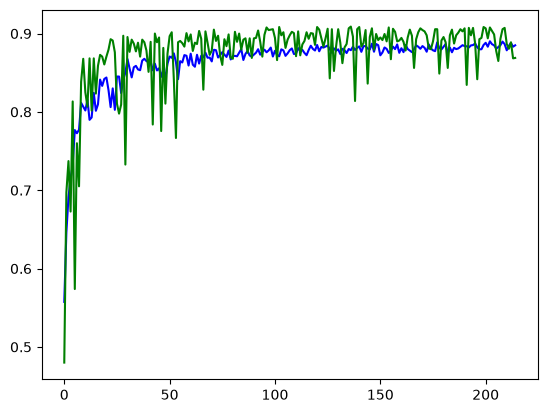

In [47]:
plt.plot(his.history["accuracy"] , color="blue")
plt.plot(his.history["val_accuracy"] , color="green")
plt.show()

In [48]:
from sklearn.metrics import accuracy_score , recall_score , confusion_matrix , precision_score
pred = model.predict(X_test)
pred_train = model.predict(X_train)

a = accuracy_score(Y_test , pred.round())
at = accuracy_score(Y_train , pred_train.round())
r = recall_score(Y_test , pred.round())
c = confusion_matrix(Y_test , pred.round())
p = precision_score(Y_test , pred.round())
a ,at, c , p , r

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(0.905,
 0.8947222222222222,
 array([[1197,   62],
        [ 109,  432]]),
 0.8744939271255061,
 0.7985212569316081)

C:\Users\mahan.ly\AppData\Local\Temp\ipykernel_9460\3356337682.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette='viridis')


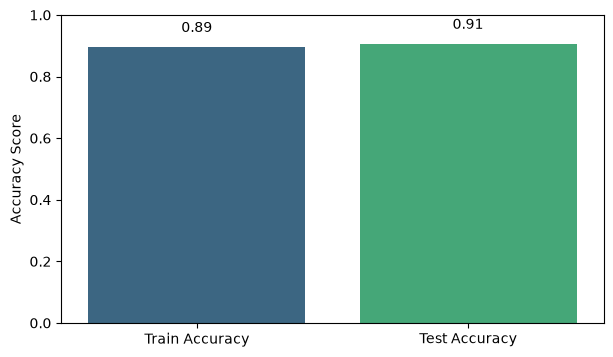

In [49]:
accuracy_scores = {'Train Accuracy': at, 'Test Accuracy': a}
labels = list(accuracy_scores.keys())
values = list(accuracy_scores.values())

plt.figure(figsize=(7, 4))
sns.barplot(x=labels, y=values, palette='viridis')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
for index, value in enumerate(values):
    plt.text(index, value + 0.05, f'{value:.2f}', color='black', ha="center")
plt.show()

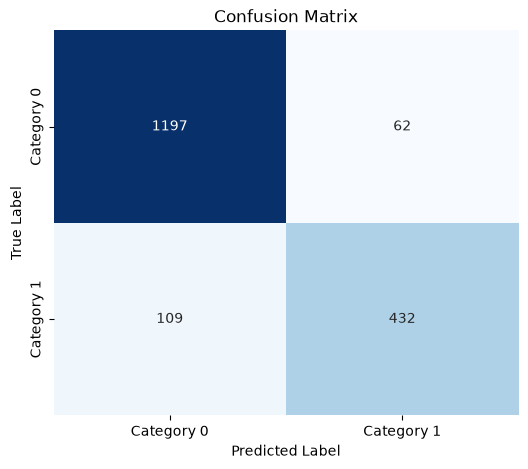

In [50]:
plt.figure(figsize=(6, 5))
sns.heatmap(c, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Category 0', 'Category 1'],
            yticklabels=['Category 0', 'Category 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [53]:
with open("model.pkl" , "wb") as f:
    pickle.dump(model , f)

with open("OneHotEncoder.pkl" , "wb") as f :
    pickle.dump(ohe , f)